In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA = PROJECT_ROOT / "data"

HISTORICAL = DATA / "historical"
OPTIONS = DATA / "options"
REPORT = PROJECT_ROOT / "report"

In [3]:
spy = pd.read_csv(
    HISTORICAL / "SPY_1Y.csv",
    skiprows=[1]
)

numeric_cols = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

spy[numeric_cols] = spy[numeric_cols].apply(pd.to_numeric)

spy.head()

,Close,High,Low,Open,Volume
0,625.845459,626.498200,621.246394,622.156295,64357500
1,625.321228,629.999373,622.215625,629.267492,74205800
2,630.197205,630.662085,626.794901,627.111401,64051600
3,628.951050,631.947874,627.704848,630.474212,58742300
4,635.646851,635.805071,629.811484,631.295045,64730800


In [5]:
import yfinance as yf

vix = yf.download("^VIX", period="1y", auto_adjust=True)

# Flatten columns if needed
if hasattr(vix.columns, "levels"):
    vix.columns = vix.columns.get_level_values(0)

vix.to_csv(HISTORICAL / "VIX_1Y.csv")

print("VIX data saved.")

[*********************100%***********************]  1 of 1 completed

VIX data saved.


In [6]:
vix = pd.read_csv(
    HISTORICAL / "VIX_1Y.csv",
    skiprows=[1]
)

numeric_cols = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

vix[numeric_cols] = vix[numeric_cols].apply(pd.to_numeric)

vix.head()

,Date,Close,High,Low,Open,Volume
0,2025-08-07,16.57,17.639999,15.98,16.41,0
1,2025-08-08,15.15,16.520000,15.15,16.48,0
2,2025-08-11,16.25,16.360001,15.52,15.81,0
3,2025-08-12,14.73,16.559999,14.66,16.09,0
4,2025-08-13,14.49,14.810000,14.30,14.62,0


In [7]:
calls = pd.read_csv(
    OPTIONS / "SPY_Calls.csv"
)

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260806C00630000,2026-08-05 18:08:22+00:00,630.0,141.86,0.0,0.0,0.0,0.0,1.0,1,0.00001,True,REGULAR,USD
1,SPY260806C00675000,2026-07-30 14:47:04+00:00,675.0,63.40,0.0,0.0,0.0,0.0,NaN,0,0.00001,True,REGULAR,USD
2,SPY260806C00680000,2026-08-05 19:59:32+00:00,680.0,90.70,0.0,0.0,0.0,0.0,10.0,8,0.00001,True,REGULAR,USD
3,SPY260806C00685000,2026-07-27 15:32:15+00:00,685.0,54.90,0.0,0.0,0.0,0.0,1.0,1,0.00001,True,REGULAR,USD
4,SPY260806C00700000,2026-08-03 14:23:19+00:00,700.0,54.45,0.0,0.0,0.0,0.0,2.0,1,0.00001,True,REGULAR,USD


In [8]:
spy_price = spy["Close"].iloc[-1]

print(f"Current SPY Price : {spy_price:.2f}")

Current SPY Price : 769.79


In [9]:
returns = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

hv = (
    returns
    .rolling(20)
    .std()
    .iloc[-1]
    * np.sqrt(252)
)

print(f"Historical Volatility : {hv*100:.2f}%")

Historical Volatility : 14.47%


In [10]:
calls["Distance"] = abs(
    calls["strike"] - spy_price
)

atm = calls.loc[
    calls["Distance"].idxmin()
]

atm

contractSymbol              SPY260806C00770000
lastTradeDate        2026-08-05 20:14:59+00:00
strike                                   770.0
lastPrice                                 2.74
bid                                        0.0
ask                                        0.0
change                                     0.0
percentChange                              0.0
volume                                 19182.0
openInterest                              6232
impliedVolatility                     0.001963
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Distance                              0.210022
Name: 63, dtype: object

In [11]:
iv = atm["impliedVolatility"]

print(f"Implied Volatility : {iv*100:.2f}%")

Implied Volatility : 0.20%


In [12]:
latest_vix = vix["Close"].iloc[-1]

print(f"Latest VIX : {latest_vix:.2f}")

Latest VIX : 15.94


In [13]:
spread = iv - hv

print(f"IV-HV Spread : {spread*100:.2f}%")

IV-HV Spread : -14.28%


In [14]:
if iv > hv:

    volatility_view = "Options appear relatively expensive."

else:

    volatility_view = "Options appear relatively inexpensive."


if latest_vix > 25:

    vix_view = "High VIX"

elif latest_vix < 20:

    vix_view = "Low VIX"

else:

    vix_view = "Moderate VIX"

print(volatility_view)
print(vix_view)

Options appear relatively inexpensive.
Low VIX


In [15]:
if iv > hv and latest_vix > 25:

    strategy = "Selling Options"

elif iv < hv and latest_vix < 20:

    strategy = "Buying Options"

else:

    strategy = "Neutral / Wait for Confirmation"

print("Suggested Strategy :", strategy)

Suggested Strategy : Buying Options


In [16]:
summary = pd.DataFrame({

    "Metric":[

        "Current SPY Price",
        "Historical Volatility",
        "Implied Volatility",
        "IV-HV Spread",
        "Latest VIX",
        "Suggested Strategy"

    ],

    "Value":[

        round(spy_price,2),
        round(hv*100,2),
        round(iv*100,2),
        round(spread*100,2),
        round(latest_vix,2),
        strategy

    ]

})

summary

,Metric,Value
0,Current SPY Price,769.79
1,Historical Volatility,14.47
2,Implied Volatility,0.2
3,IV-HV Spread,-14.28
4,Latest VIX,15.94
5,Suggested Strategy,Buying Options


In [17]:
summary.to_csv(

    REPORT /
    "Day43_Strategy_Analysis.csv",

    index=False

)

print("Summary Saved")

Summary Saved


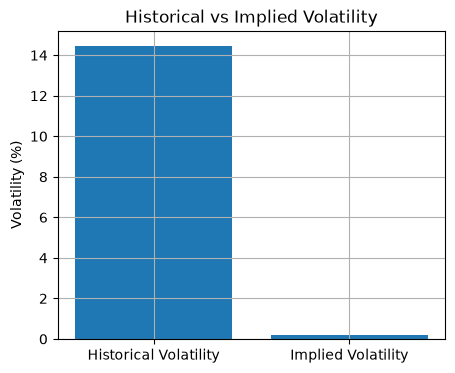

In [18]:
plt.figure(figsize=(5,4))

plt.bar(

    ["Historical Volatility","Implied Volatility"],

    [hv*100, iv*100]

)

plt.ylabel("Volatility (%)")

plt.title("Historical vs Implied Volatility")

plt.grid()

plt.savefig(

    REPORT /
    "IV_vs_HV.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [19]:
print("----------- DAY 43 MARKET ANALYSIS -----------\n")

print(f"Current SPY Price      : {spy_price:.2f}")

print(f"Historical Volatility  : {hv*100:.2f}%")

print(f"Implied Volatility     : {iv*100:.2f}%")

print(f"IV-HV Spread           : {spread*100:.2f}%")

print()

print(f"Latest VIX             : {latest_vix:.2f}")

print()

print(volatility_view)

print(vix_view)

print()

print(f"Suggested Strategy     : {strategy}")

print("\nAnalysis Complete.")

----------- DAY 43 MARKET ANALYSIS -----------

Current SPY Price      : 769.79
Historical Volatility  : 14.47%
Implied Volatility     : 0.20%
IV-HV Spread           : -14.28%

Latest VIX             : 15.94

Options appear relatively inexpensive.
Low VIX

Suggested Strategy     : Buying Options

Analysis Complete.
